In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
import os
import seaborn as sns
from os.path import exists
import pickle
from matplotlib.cm import get_cmap
import matplotlib as mpl
from scipy.interpolate import make_interp_spline
from scipy import stats
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, spearmanr
import statsmodels.formula.api as smf

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
data_dir = '../data/GBM/'
clone_dir = '../data/GBM/clones/'
save_dir = '../data/cell2fate/'

outdir = '../data/trajectories/plots/'
patients = np.array(('at12', 'at14', 'at4', 'at6', 'at9', 'at11',
                     'at13', 'at15', 'at5', 'at7', 'at10', 'at3'))

# Extract results from cell2fate runs on all patients, calculate time for each cluster and remove rare cell types:

In [ ]:
path = save_dir
time_tab_list = []
seed = 0
for i in range(len(patients)):
    patient = patients[i]
    print(patient)
    clones = pd.read_csv(clone_dir + patient + '_2.h5ad')
    unique_clones = np.unique(clones['predicted'])
    for j in range(len(unique_clones)):
        print(j)
        filename = save_dir + patient + 'clone' + str(unique_clones[j]) + '_2_new2.pickle'
        with open(filename, 'rb') as handle:
            post_sample_means = pickle.load(handle)
        obs = pd.DataFrame(index = post_sample_means['obs_names'], columns = ['obs_names', 'Time (hours)', 'TME_GBM_granular'])
        obs['obs_names'] = post_sample_means['obs_names']
        obs['Time (hours)'] = post_sample_means['T_c'][:,0,0] - np.min(post_sample_means['T_c'][:,0,0])
        obs['Time (scaled)'] = obs['Time (hours)']/obs['Time (hours)'].max()
        obs['TME_GBM_granular'] = post_sample_means['TME_GBM_granular']
        obs['Patient_Clone'] = patient + '_' + unique_clones[j]
        GBM_remap = pd.read_csv('../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', sep = '\t').fillna('')
        obs = obs.reset_index().merge(GBM_remap, on = 'TME_GBM_granular', how = 'left').set_index('index')
        obs['Celltype'] = obs['cell_class']
        obs.to_csv('../data/cell2fate/LatestRun' + patients[i] + '_' + unique_clones[j] + '.csv')

        unique_celltypes = list(np.unique(obs['Celltype']))
        time_tab_list += [obs]
res_tab = pd.concat(time_tab_list, axis = 0)

at12
0
1
2
3
4
5
at14
0
1
2
3
4
at4
0
1
2
3
at6


/tmp/ipykernel_985760/335521709.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  clones = pd.read_csv(clone_dir + patient + '_2.h5ad')


0
1
2
3
4
5
6
7
at9


/tmp/ipykernel_985760/335521709.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  clones = pd.read_csv(clone_dir + patient + '_2.h5ad')


0
1
2
3
4
5
at11
0
1
2
3
4
at13
0
1
at15


/tmp/ipykernel_985760/335521709.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  clones = pd.read_csv(clone_dir + patient + '_2.h5ad')


0
1
2
3
4
5
6
7
at5
0
1
2
3
4
5
6
7
8
9
10
at7
0
1
2
at10
0
1
2
3
4
5
at3


/tmp/ipykernel_985760/335521709.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  clones = pd.read_csv(clone_dir + patient + '_2.h5ad')


0
1
2
3
4
5


# Load results

In [ ]:
all_scores = pd.read_csv(outdir+'transition_scores.csv', index_col=0)
high_score_clones = all_scores[all_scores['pass']==True]['index'].tolist()

In [ ]:
res_tab = []
for clone in high_score_clones:
    res_tab.append(pd.read_csv('../data/cell2fate/LatestRun{}.csv'.format(clone)))
res_tab = pd.concat(res_tab)

Remove results where cell2fate didnt work (low maximal time):

In [ ]:
unique_patientClones = np.unique(res_tab['Patient_Clone'])
good_patientClones = []
for i in range(len(unique_patientClones)):
    if np.max(res_tab.loc[res_tab['Patient_Clone'] == unique_patientClones[i],:].loc[:,'Time (hours)']) > 20:
        if 'diploid' not in unique_patientClones[i]:
            good_patientClones += [unique_patientClones[i]]
res_tab = res_tab.loc[[x in good_patientClones for x in res_tab['Patient_Clone']],:]
res_tab['Patient_Clone'].value_counts()

at15_4    25146
at6_5     21882
at15_6    14901
at4_0     14602
at9_0     12423
at9_4     11929
at9_2     11317
at3_3      7077
at13_0     6882
at10_1     6519
at7_0      5895
at4_1      5804
at10_2     5440
at4_2      4670
at6_4      4132
at6_0      3476
at15_2     3109
at15_0     2879
at5_2      2734
at10_0     2731
at15_3     2691
at5_9      2216
at5_4      2161
at3_1      1936
at5_8      1928
at14_2     1894
at7_1      1598
at15_5     1256
Name: Patient_Clone, dtype: int64

Summarize results over all patients:

In [ ]:
good_clones = res_tab['Patient_Clone'].value_counts()[
    res_tab['Patient_Clone'].value_counts()>=2000].index.tolist()

In [ ]:
unique_celltypes = np.unique(res_tab['Celltype'])
summarized_results = pd.DataFrame(index = unique_celltypes, columns = ('Mean', 'Median', 'Var', 'Order', 'ELBO'))
for i in range(len(unique_celltypes)):
    summarized_results.loc[unique_celltypes[i],:] = np.mean(res_tab['Time (hours)'].loc[res_tab['Celltype'] == unique_celltypes[i]])

In [ ]:
res_tab = []
for clone in good_clones:
    clone = clone.lower()
    res_tab.append(pd.read_csv('../data/cell2fate/LatestRun{}.csv'.format(clone)))
res_tab = pd.concat(res_tab)

# Diversity

In [ ]:
from scipy.stats import entropy

counts = res_tab.groupby(['Patient_Clone', 'cell_class'], as_index=False).size()\
    .pivot(index = 'Patient_Clone', columns = 'cell_class', values = 'size')
diversity = counts.divide(counts.sum(axis=1), axis=0).apply(entropy, axis=1).sort_values()

# Clustering good clones

In [ ]:
N_bins = 10

In [ ]:
clust_tab = []
for i in range(len(good_clones)):

    subset = np.array(res_tab['Patient_Clone'] == good_clones[i].lower())
    sub_tab = res_tab.loc[subset,:].reset_index(drop=True)

    # Get bin widths
    sub_tab['time'] = (sub_tab['Time (hours)']-sub_tab['Time (hours)'].min())/sub_tab['Time (hours)'].max()
    clust_tab.append(sub_tab)
clust_tab = pd.concat(clust_tab)

In [ ]:
bin_edges = np.linspace(0, 1, N_bins + 1)
clust_tab['bin'] = pd.cut(clust_tab['time'], bins=bin_edges, right=False)

In [ ]:
grouped = clust_tab.groupby(['bin', 
                             'cell_class', 
                             'Patient_Clone'], as_index=False, observed=True).size()

grouped = grouped.pivot(index=['bin', 'Patient_Clone'], 
              columns = 'cell_class', 
              values='size').fillna(0).idxmax(axis=1)\
        .reset_index().rename(columns={0:'class'})

order = ['Neuron-like', 'OPC-NPC-like', 'Proliferative', 'AC-gliosis-hypoxia']
grouped["class"] = pd.Categorical(
    grouped["class"],
    categories=order,
    ordered=True
)
grouped["category_code"] = grouped["class"].cat.codes

grouped = grouped.pivot(index = 'Patient_Clone', 
    columns = 'bin', 
    values = 'category_code').fillna(-1)

In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import squareform

def manhattan_ignore_nan(u, v):
    mask = (u != -1) & (v != -1)
    if mask.sum() == 0:
        return np.inf
    return np.mean(np.abs(u[mask] - v[mask]))

In [ ]:
dist = pdist(grouped.values, metric=manhattan_ignore_nan)
row_linkage = linkage(dist, method="average")

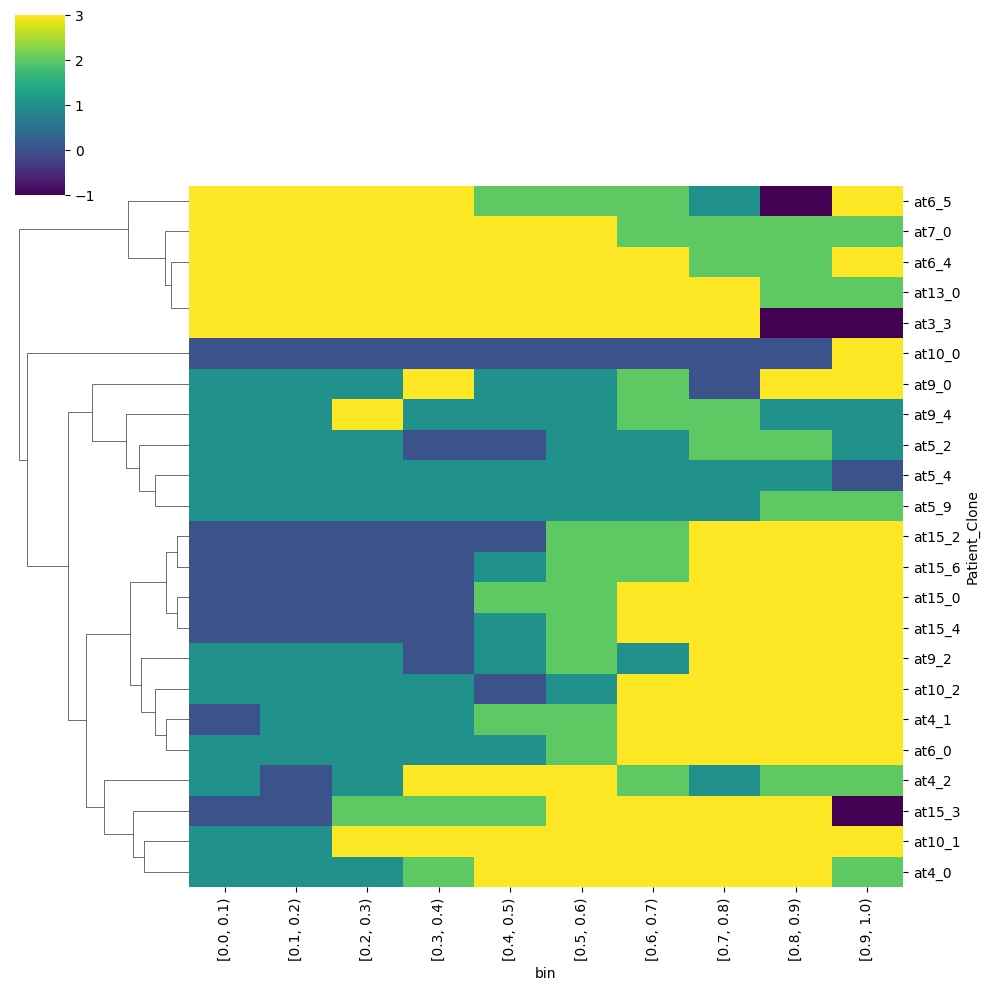

In [ ]:
g = sns.clustermap(
    grouped,
    row_linkage=row_linkage,
    col_cluster=False,
    cmap="viridis"
)

In [ ]:
ordered_df = g.data2d
ordered_samples = g.data2d.index

In [ ]:
good_clones = [
 'at6_5',
 'at7_0',
 'at6_4',
 'at13_0',
 'at3_3',
 'at5_4',
 'at5_9',
 'at9_0',
 'at9_4',
 'at5_2',
 'at10_0',
 'at15_2',
 'at15_6',
 'at15_0',
 'at15_4',
 'at9_2',
 'at10_2',
 'at4_1',
 'at6_0',
 'at4_2',
 'at15_3',
 'at10_1',
 'at4_0']
good_clones.reverse()
good_clones

['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_2',
 'at9_4',
 'at9_0',
 'at5_9',
 'at5_4',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']

In [ ]:
diversity[good_clones]

Patient_Clone
at4_0     1.083917
at10_1    0.968734
at15_3    1.267656
at4_2     1.146241
at6_0     0.539449
at4_1     1.168363
at10_2    0.901648
at9_2     0.769413
at15_4    0.854976
at15_0    1.010852
at15_6    0.919802
at15_2    1.078853
at10_0    0.777514
at5_2     0.924304
at9_4     0.838509
at9_0     0.825188
at5_9     0.591862
at5_4     0.506901
at3_3     0.557300
at13_0    0.341140
at6_4     0.312086
at7_0     0.715430
at6_5     0.611521
dtype: float64

# Latent time streamgraph

In [ ]:
good_clones = [
 'at6_5',
 'at7_0',
 'at6_4',
 'at13_0',
 'at3_3',
 'at5_4',
 'at5_9',
 'at9_0',
 'at9_4',
 'at5_2',
 'at10_0',
 'at15_2',
 'at15_6',
 'at15_0',
 'at15_4',
 'at9_2',
 'at10_2',
 'at4_1',
 'at6_0',
 'at4_2',
 'at15_3',
 'at10_1',
 'at4_0']
good_clones.reverse()
good_clones

['at4_0',
 'at10_1',
 'at15_3',
 'at4_2',
 'at6_0',
 'at4_1',
 'at10_2',
 'at9_2',
 'at15_4',
 'at15_0',
 'at15_6',
 'at15_2',
 'at10_0',
 'at5_2',
 'at9_4',
 'at9_0',
 'at5_9',
 'at5_4',
 'at3_3',
 'at13_0',
 'at6_4',
 'at7_0',
 'at6_5']

In [ ]:
res_tab = []
for clone in good_clones:
    clone = clone.lower()
    res_tab.append(pd.read_csv('../data/cell2fate/LatestRun{}.csv'.format(clone)))
res_tab = pd.concat(res_tab)

In [ ]:
prolif_anno = pd.read_csv('../data/proliferative/proliferative_annotation_granular.csv', 
                          index_col=0)

non_prolif_annotation = {
    'Proliferative 0':'AC-gliosis-hypoxia',
    'Proliferative 1':'Neuron-like',
    'Proliferative 2':'OPC-NPC-like',
    'Proliferative 3':'OPC-NPC-like',
    'Proliferative 4':'AC-gliosis-hypoxia',
    'Proliferative 5':'AC-gliosis-hypoxia'
}

prolif_annotation = {
    'Proliferative 0':'Cycling AC',
    'Proliferative 1':'Cycling Neuron-like',
    'Proliferative 2':'Cycling NPC-OPC',
    'Proliferative 3':'Cycling NPC-OPC',
    'Proliferative 4':'Cycling AC',
    'Proliferative 5':'Cycling AC'
}

# set up MERGED prolif columns - coarsed grained
prolif_anno['non_prolif_annotation'] = prolif_anno['annotation_granular_prolif'].map(non_prolif_annotation)
prolif_anno['annotation_granular_non_prolif'] = np.where(
    ~prolif_anno['non_prolif_annotation'].isnull(), prolif_anno['non_prolif_annotation'],
    prolif_anno['annotation_granular_prolif']
)
prolif_anno = prolif_anno.drop('non_prolif_annotation', axis=1)
prolif_anno = prolif_anno.rename(columns={'cell_id':'obs_names'})

# set up MERGED prolif columns - coarsed grained
prolif_anno['prolif_annotation'] = prolif_anno['annotation_granular_prolif'].map(prolif_annotation)
prolif_anno['annotation_granular_prolif'] = np.where(
    ~prolif_anno['prolif_annotation'].isnull(), prolif_anno['prolif_annotation'],
    prolif_anno['annotation_granular_prolif'])
prolif_anno = prolif_anno.drop('prolif_annotation', axis=1)
prolif_anno = prolif_anno.rename(columns={'cell_id':'obs_names'})

res_tab = res_tab.merge(prolif_anno, on = 'obs_names', how = 'left')

In [ ]:
len(res_tab['annotation_granular_prolif'].dropna())==len(res_tab['annotation_granular_prolif'])

True

In [ ]:
res_tab['cell_class_no_prolif'] = np.where(
    res_tab['cell_class']=='Proliferative', res_tab['annotation_granular_non_prolif'],
    res_tab['cell_class']
)

res_tab['cell_class_prolif'] = np.where(
    res_tab['cell_class']=='Proliferative', res_tab['annotation_granular_prolif'],
    res_tab['cell_class']
)

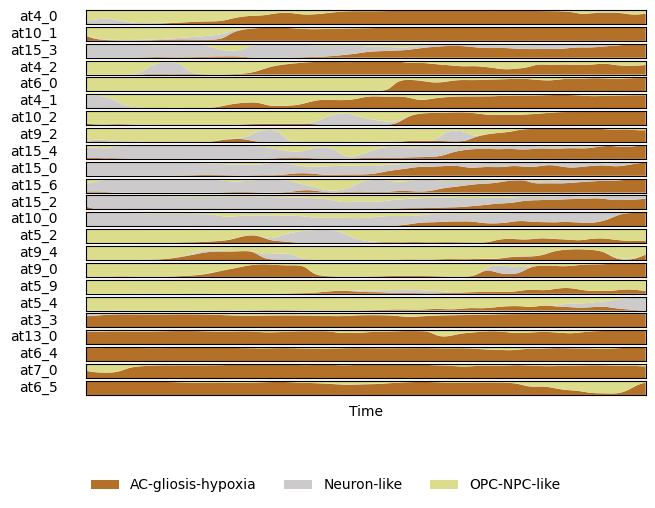

In [ ]:
def gaussian_smooth(x, y, grid, sd):
    weights = np.transpose([stats.norm.pdf(grid, m, sd) for m in x])
    weights = weights / weights.sum(0)
    return (weights * y).sum(1)

N_bins = 100

color_set = {'AC-gliosis-hypoxia':'#B37029', # ac-gliosis
             'Neuron-like':'#CCCACB', 
             'OPC-NPC-like':'#DBDD8C'} # others

clones = [i.lower() for i in good_clones]
fig, ax = plt.subplots(len(clones), 1, figsize=(8, 5.5), sharex=False)

plot_out = []
out_df = []
for i in range(len(clones)):
    subset = np.array(res_tab['Patient_Clone'] == clones[i])
    sub_tab = res_tab.loc[subset, :].reset_index(drop=True)

    sub_tab['time'] = (
        sub_tab['Time (hours)'] - sub_tab['Time (hours)'].min()
    ) / sub_tab['Time (hours)'].max()

    bin_edges = np.linspace(0, 1, N_bins + 1)
    sub_tab['bin'] = pd.cut(sub_tab['time'], bins=bin_edges, 
                            right=True, include_lowest=True)

    out_df.append(sub_tab.drop('bin', axis=1))

    grouped = (
        sub_tab
        .groupby(['bin', 'cell_class_no_prolif'], observed=True)
        .size()
        .unstack(fill_value=0)
    )

    percentages = grouped.div(grouped.sum(axis=1), axis=0).fillna(0)

    x = np.arange(len(grouped))
    y = grouped.values.T

    grid = np.linspace(x.min(), x.max(), num=200)
    y_smoothed = [gaussian_smooth(x, y_, grid, 1.5) for y_ in y]

    y_smoothed = np.vstack(y_smoothed)
    y_smoothed = y_smoothed / y_smoothed.sum(axis=0)

    labels = percentages.columns
    colors = labels.map(color_set)

    ax[i].stackplot(grid, y_smoothed, labels=labels, colors=colors)

    ax[i].set_yticks([])
    ax[i].set_xticks([])
    ax[i].set_yticklabels([])
    ax[i].text(
        -0.05, 0.5, clones[i],
        va='center',
        ha='right',
        transform=ax[i].transAxes
    )

    if i == len(clones) - 1:
        ax[i].set_xlabel('Time')

    ax[i].tick_params(axis='y', which='both', left=False, right=False)
    ax[i].margins(x=0)

    #plot_out[clones[i]] = {'grid':grid, 'y_smoothed':y_smoothed}
    source_out = pd.DataFrame(y_smoothed)
    source_out.index = labels
    source_out = source_out.T
    source_out['grid'] = grid
    source_out['clone'] = clones[i]
    plot_out.append(source_out)

# Legend from color_set dictionary
legend_handles = [
    Patch(facecolor=color, edgecolor='none', label=label)
    for label, color in color_set.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False
)

plt.subplots_adjust(left=0.2, bottom=0.18)

plt.savefig(
    outdir + 'all_clones_c2f_colorbars_cutoff09_11_smoothed.pdf',
    bbox_inches='tight'
)

In [ ]:
out_df = pd.concat(out_df)
out_df.to_csv(outdir+'min_max_laten_time_df_prolif_merged.csv')

plot_out = pd.concat(plot_out)
plot_out.to_csv('../../../data/Fig5/Fig5a1.csv')

# Latent time bar plots

In [ ]:
color_dict = {'AC-gliosis-hypoxia':'#B37029', # ac-gliosis
             'Cycling AC':'#e0bc96', 
             'Cycling NPC-OPC':'#f4f5d7',
             'Cycling Neuron-like':'#d1e4eb',
             'Neuron-like':'#CCCACB', 
             'OPC-NPC-like':'#DBDD8C'} # others

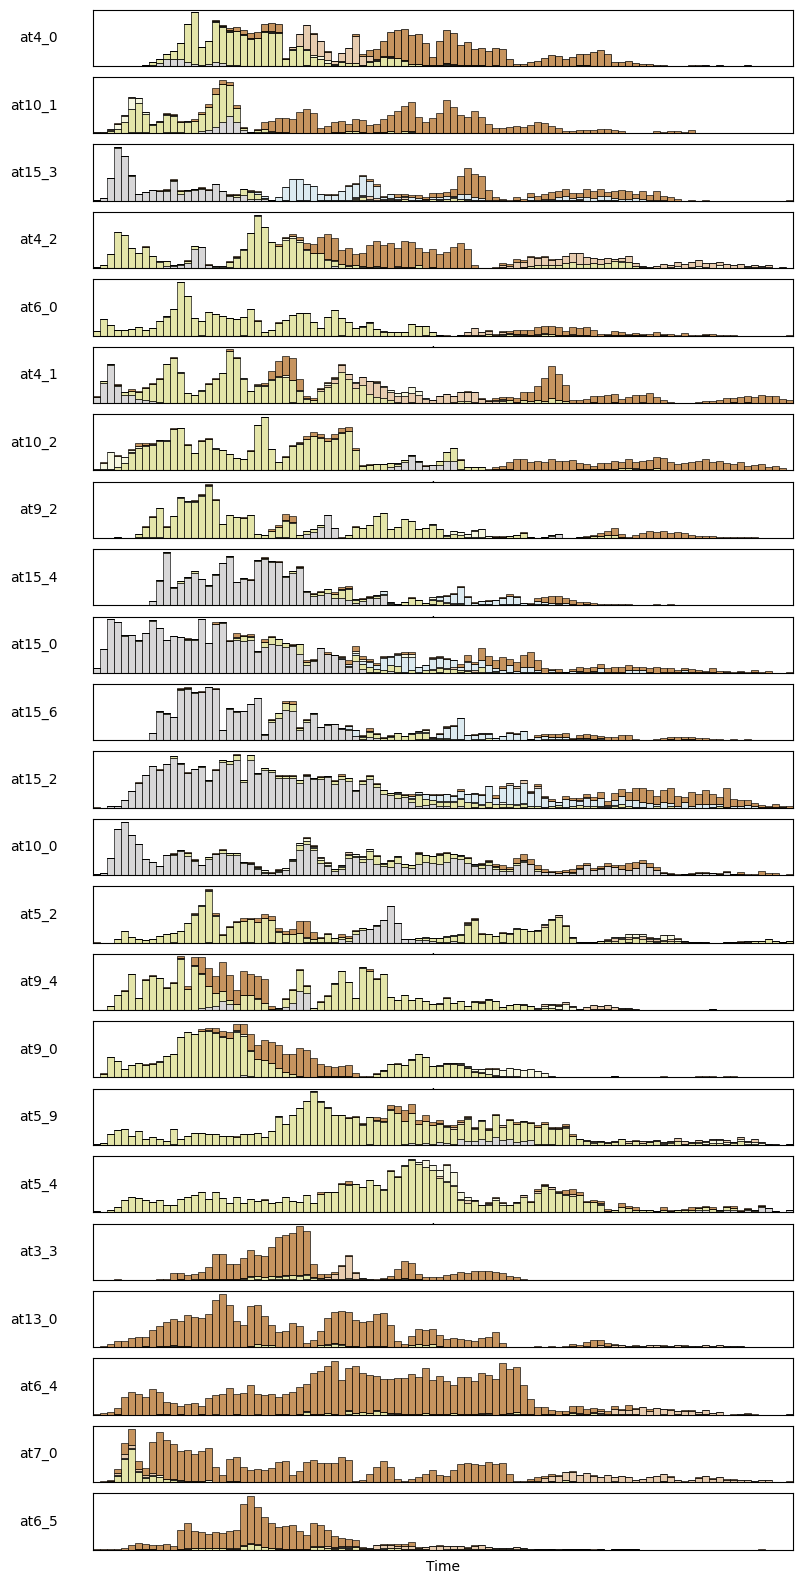

In [ ]:
N=50

clones = [i.lower() for i in good_clones]
fig, ax = plt.subplots(len(clones),1, figsize = (10, 20), sharex = False)
for i in range(len(clones)):
    subset = np.array(res_tab['Patient_Clone'] == clones[i])
    sub_tab = res_tab.loc[subset,:].reset_index(drop=True)

    # Get bin widths
    sub_tab['time'] = (sub_tab['Time (hours)']-sub_tab['Time (hours)'].min())/sub_tab['Time (hours)'].max()

    labels = sub_tab['cell_class_prolif'].drop_duplicates().tolist()

    sns.histplot(data=sub_tab, x="time", hue="cell_class_prolif", multiple="stack", 
                 palette = [color_dict[i] for i in labels], ax = ax[i], legend=False, bins = N_bins)

    ax[i].set_yticks([])
    ax[i].set_xticks([])
    ax[i].set_ylabel('')
    ax[i].set_yticklabels([])
    ax[i].text(-0.05, 0.5, clones[i], va='center', ha='right', transform=ax[i].transAxes)
    if i == (len(clones)-1):
        ax[i].set_xlabel('Time')
    ax[i].tick_params(axis='y', which='both', left=False, right=False)
    ax[i].margins(x=0)
    plt.subplots_adjust(left=0.2)
    plt.savefig(outdir+'all_clones_c2f_colorbars_barplot.pdf')

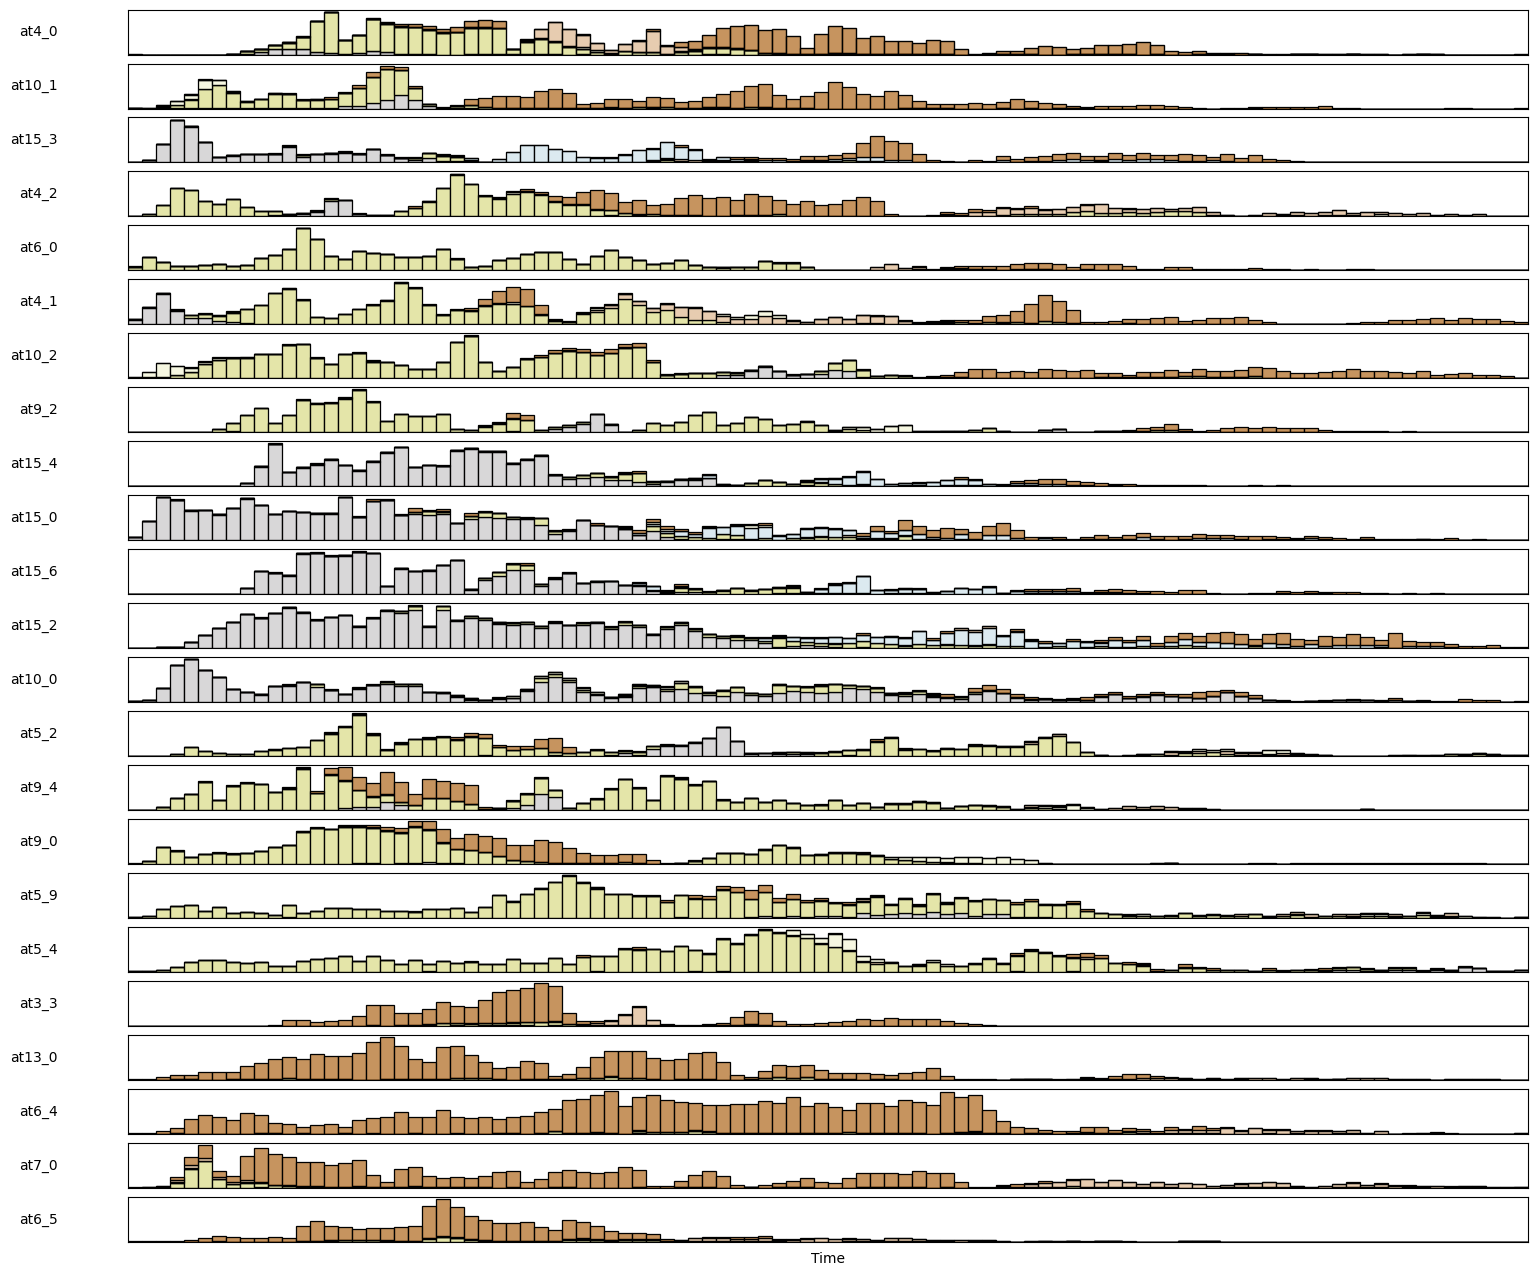

In [ ]:
clones = [i.lower() for i in good_clones]
N_bins = 100

plot_out2 = []
fig, ax = plt.subplots(len(clones),1, figsize = (20, 16), sharex = False)
for i in range(len(clones)):
    subset = np.array(res_tab['Patient_Clone'] == clones[i])
    sub_tab = res_tab.loc[subset,:].reset_index(drop=True)

    # Get bin widths
    sub_tab['time'] = (sub_tab['Time (hours)']-sub_tab['Time (hours)'].min())/sub_tab['Time (hours)'].max()

    labels = sub_tab['cell_class_prolif'].drop_duplicates().tolist()

    sns.histplot(data=sub_tab, x="time", hue="cell_class_prolif", multiple="stack", 
                 palette = [color_dict[i] for i in labels], ax = ax[i], legend=False, bins = N_bins)
    plot_out2.append(sub_tab)
    
    ax[i].set_yticks([])
    ax[i].set_xticks([])
    ax[i].set_ylabel('')
    ax[i].set_yticklabels([])
    ax[i].text(-0.05, 0.5, clones[i], va='center', ha='right', transform=ax[i].transAxes)
    if i == (len(clones)-1):
        ax[i].set_xlabel('Time')
    ax[i].tick_params(axis='y', which='both', left=False, right=False)
    ax[i].margins(x=0)
    plt.subplots_adjust(left=0.2)
    plt.savefig(outdir+'all_clones_c2f_colorbars_barplot.pdf')

In [ ]:
plot_out2 = pd.concat(plot_out2)
plot_out2[['obs_names', 'Patient_Clone', 'time', 'cell_class_prolif']]\
    .to_csv('../../../data/EDFig7/EDFig7a.csv')

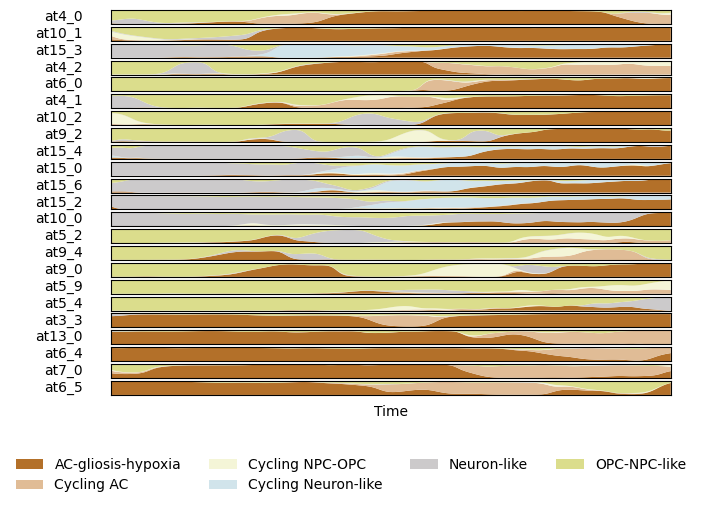

In [ ]:
N_bins = 100
    
color_set = {'AC-gliosis-hypoxia':'#B37029', # ac-gliosis
             'Cycling AC':'#e0bc96', 
             'Cycling NPC-OPC':'#f4f5d7',
             'Cycling Neuron-like':'#d1e4eb',
             'Neuron-like':'#CCCACB', 
             'OPC-NPC-like':'#DBDD8C'} # others

clones = [i.lower() for i in good_clones]
fig, ax = plt.subplots(len(clones), 1, figsize=(8, 5.5), sharex=False)

for i in range(len(clones)):
    subset = np.array(res_tab['Patient_Clone'] == clones[i])
    sub_tab = res_tab.loc[subset, :].reset_index(drop=True)

    sub_tab['time'] = (
        sub_tab['Time (hours)'] - sub_tab['Time (hours)'].min()
    ) / sub_tab['Time (hours)'].max()

    bin_edges = np.linspace(0, 1, N_bins + 1)
    sub_tab['bin'] = pd.cut(sub_tab['time'], bins=bin_edges, right=False)

    grouped = (
        sub_tab
        .groupby(['bin', 'cell_class_prolif'], observed=True)
        .size()
        .unstack(fill_value=0)
    )

    percentages = grouped.div(grouped.sum(axis=1), axis=0).fillna(0)

    x = np.arange(len(grouped))
    y = grouped.values.T

    grid = np.linspace(x.min(), x.max(), num=200)
    y_smoothed = [gaussian_smooth(x, y_, grid, 1.5) for y_ in y]

    y_smoothed = np.vstack(y_smoothed)
    y_smoothed = y_smoothed / y_smoothed.sum(axis=0)

    labels = percentages.columns
    colors = labels.map(color_set)

    ax[i].stackplot(grid, y_smoothed, labels=labels, colors=colors)

    ax[i].set_yticks([])
    ax[i].set_xticks([])
    ax[i].set_yticklabels([])
    ax[i].text(
        -0.05, 0.5, clones[i],
        va='center',
        ha='right',
        transform=ax[i].transAxes
    )

    if i == len(clones) - 1:
        ax[i].set_xlabel('Time')

    ax[i].tick_params(axis='y', which='both', left=False, right=False)
    ax[i].margins(x=0)

# Legend from color_set dictionary
legend_handles = [
    Patch(facecolor=color, edgecolor='none', label=label)
    for label, color in color_set.items()
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False
)

plt.subplots_adjust(left=0.2, bottom=0.18)

plt.savefig(
    outdir + 'all_clones_streamgraph_coarse_cycling.pdf',
    bbox_inches='tight'
)

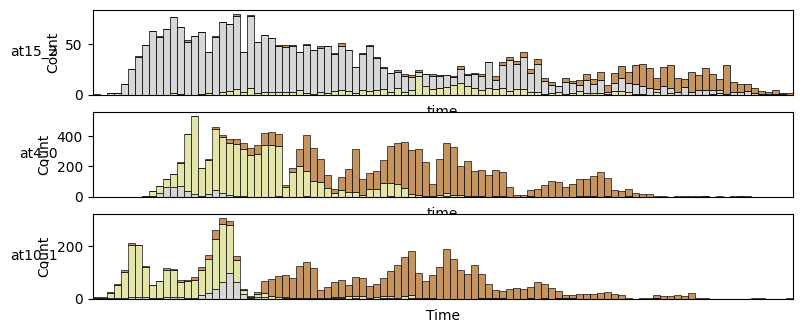

In [ ]:
clones = ['at15_2', 'at4_0', 'at10_1']
fig, ax = plt.subplots(len(clones),1, figsize = (10, 3.75), sharex = False)
for i in range(len(clones)):
    subset = np.array(res_tab['Patient_Clone'] == clones[i])
    sub_tab = res_tab.loc[subset,:].reset_index(drop=True)

    # Get bin widths
    sub_tab['time'] = (sub_tab['Time (hours)']-sub_tab['Time (hours)'].min())/sub_tab['Time (hours)'].max()

    labels = sub_tab['cell_class_no_prolif'].drop_duplicates().tolist()

    sns.histplot(data=sub_tab, x="time", hue="cell_class_no_prolif", multiple="stack", 
                 palette = [color_dict[i] for i in labels], ax = ax[i], legend=False, bins = N_bins)

    ax[i].set_xticks([])
    ax[i].text(-0.05, 0.5, clones[i], va='center', ha='right', transform=ax[i].transAxes)
    if i == (len(clones)-1):
        ax[i].set_xlabel('Time')
    ax[i].tick_params(axis='y', which='both', left=True, right=False)
    ax[i].margins(x=0)
    plt.subplots_adjust(left=0.2)

    if clones[i]=='at10_1':
        sub_tab[['obs_names', 'Patient_Clone', 'time', 'cell_class_no_prolif']]\
        .to_csv('../../../data/Fig5/EDFig5a2.csv')
    
plt.savefig(outdir+'all_clones_c2f_colorbars_cutoff09_11_{}.pdf'.format(clones[i]))

# Latent time per cell type

- keep diverse clones only; plot entropy and ID threshold

In [ ]:
color_set = {'AC-gliosis-hypoxia':'#B37029', # ac-gliosis
             'Neuron-like':'#CCCACB', 
             'OPC-NPC-like':'#DBDD8C'} # others


In [ ]:
# min-max time per ct
out_df = pd.read_csv(outdir+'min_max_laten_time_df_prolif_merged.csv', index_col=0)

# get high diversity clones
high_diversity = diversity[diversity>diversity.quantile(0.5)].index.tolist()

In [ ]:
time_plot_granular = out_df[out_df['Patient_Clone'].isin(high_diversity)].copy()
ordered = time_plot_granular.groupby('annotation_granular_prolif')['time'].median().sort_values()

time_plot_granular['colors'] = [color_set[i] for i in time_plot_granular['cell_class_no_prolif']]

df = time_plot_granular[['annotation_granular_prolif', 'colors']]\
    .drop_duplicates().set_index('annotation_granular_prolif')
granular_dict = df.iloc[:, 0].to_dict()

time_plot_granular["annotation_granular_prolif"] = pd.Categorical(
    time_plot_granular["annotation_granular_prolif"], 
    categories=ordered.index.tolist(), ordered=True)

/tmp/ipykernel_3716519/1645051303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = time_plot_granular,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


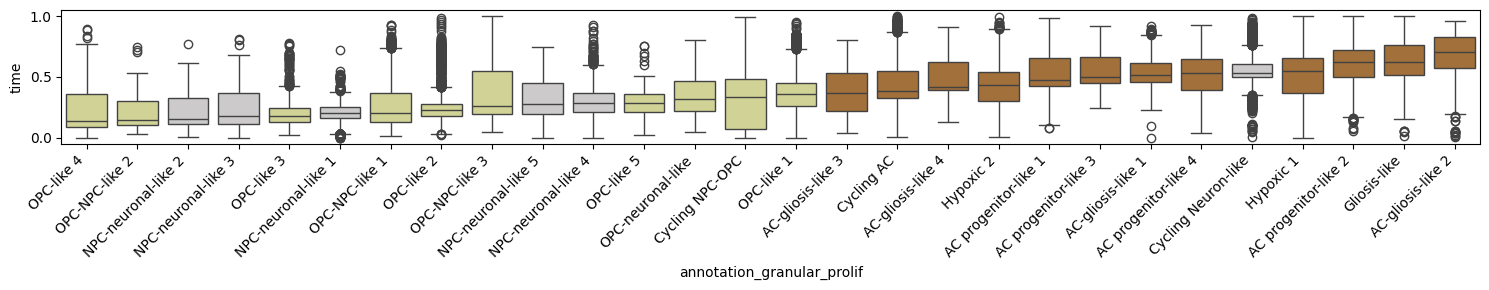

In [ ]:
plt.figure(figsize=(15, 3))

sns.boxplot(data = time_plot_granular,
            x = 'annotation_granular_prolif',
            y = 'time', palette = granular_dict)

plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
time_plot_granular[['obs_names', 'Patient_Clone', 'time', 'annotation_granular_prolif']]\
    .to_csv('../../../data/EDFig6/EDFig6d.csv')
plt.savefig(outdir+'cell_type_barplot.pdf')

In [ ]:
time_plot_coarse = out_df[out_df['Patient_Clone'].isin(high_diversity)].copy()
ordered = time_plot_coarse.groupby('annotation_coarse')['time'].median().sort_values()
time_plot_coarse['colors'] = [color_dict[i] for i in time_plot_coarse['Celltype']]

In [ ]:
time_plot_coarse["cell_class_no_prolif"] = pd.Categorical(
    time_plot_coarse["cell_class_no_prolif"], 
    categories=['Neuron-like', 'OPC-NPC-like', 
                'AC-gliosis-hypoxia'], 
    ordered=True)

/tmp/ipykernel_3716519/371806623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = time_plot_coarse,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


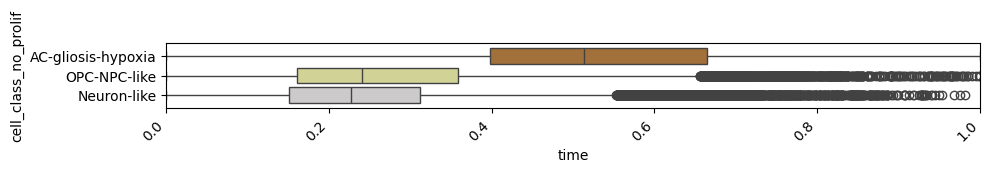

In [ ]:
plt.figure(figsize=(10, 1.5))

sns.boxplot(data = time_plot_coarse,
            y = 'cell_class_no_prolif',
            x = 'time', palette = color_dict)

plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
plt.xlim(0,1)
plt.margins(y=0.1)

time_plot_coarse[['obs_names', 'Patient_Clone', 'time', 'cell_class_no_prolif']]\
    .to_csv('../../../data/Fig5/Fig5a3.csv')

plt.savefig(outdir+'general_boxplot.pdf')

/tmp/ipykernel_3885580/3859962596.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = time_plot_coarse,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


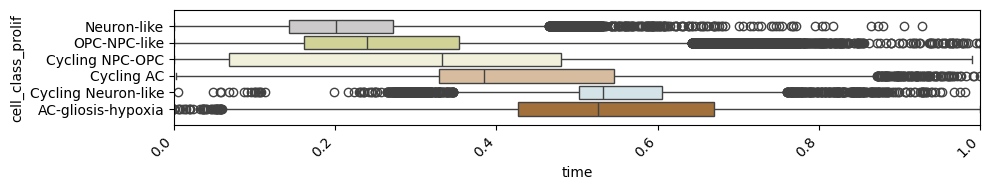

In [ ]:
time_plot_coarse["cell_class_prolif"] = pd.Categorical(
    time_plot_coarse["cell_class_prolif"], 
    categories=['Neuron-like', 'OPC-NPC-like', 
                'Cycling NPC-OPC', 'Cycling AC',
                'Cycling Neuron-like',
                'AC-gliosis-hypoxia'], 
    ordered=True)

plt.figure(figsize=(10, 2))

sns.boxplot(data = time_plot_coarse,
            y = 'cell_class_prolif',
            x = 'time', palette = color_dict)

plt.xticks(rotation=45, ha="right")
plt.legend().remove()
plt.tight_layout()
plt.xlim(0,1)
plt.margins(y=0.1)
plt.savefig(outdir+'general_boxplot_cycling.pdf')

# Test difference in distance

In [ ]:
df = out_df[out_df['Patient_Clone'].isin(good_clones)]

# separate into dev-like, ac-gliosis-hypoxia, other
df['state'] = np.where(df['cell_class_no_prolif'].isin(['OPC-NPC-like', 'Neuron-like']), 'dev-like',
                      df['cell_class_no_prolif'])
df['is_dev'] = df['cell_class_no_prolif'].isin(['OPC-NPC-like', 'Neuron-like'])

## Wilcoxon

In [ ]:
clone_diversity = pd.DataFrame(diversity, columns=['diversity']).reset_index()

clone_state_summary = (
    df.groupby(["Patient_Clone", "state"], as_index=False)
           .agg(
               n_cells=("time", "size"),
               median_pseudotime=("time", "median"),
               mean_pseudotime=("time", "mean"),
               q25_pseudotime=("time", lambda x: np.quantile(x, 0.25)),
               q75_pseudotime=("time", lambda x: np.quantile(x, 0.75))
           )
)

# Merge clone-level diversity onto the clone-state summary
clone_state_summary = clone_state_summary.merge(
    clone_diversity,
    on="Patient_Clone",
    how="left"
)

### Dev-like vs AC-gliosis-hypoxia (priortiy stat)

In [ ]:
acgliosis_label = "AC-gliosis-hypoxia"
dev_label = 'dev-like'

dev_acgliosis_summary = clone_state_summary[
    clone_state_summary["state"].isin(['dev-like', acgliosis_label])
].copy()

dev_acgliosis_wide = (
    dev_acgliosis_summary.pivot_table(
        index=["Patient_Clone", "diversity"],
        columns="state",
        values=["n_cells", "median_pseudotime", "mean_pseudotime"]
    )
)

dev_acgliosis_wide.columns = ["_".join(col) for col in dev_acgliosis_wide.columns]
dev_acgliosis_wide = dev_acgliosis_wide.reset_index()

needed_cols = [
    f"median_pseudotime_{dev_label}",
    f"median_pseudotime_{acgliosis_label}"
]
dev_acgliosis_wide = dev_acgliosis_wide.dropna(subset=needed_cols).copy()

# Positive delta means acgliosis is later than dev
dev_acgliosis_wide["delta_dev_mins_acgliosis_median_pt"] = (
    dev_acgliosis_wide[f"median_pseudotime_{dev_label}"] -
    dev_acgliosis_wide[f"median_pseudotime_{acgliosis_label}"]

)

dev_acgliosis_wide["delta_dev_mins_acgliosis_mean_pt"] = (
    dev_acgliosis_wide[f"mean_pseudotime_{dev_label}"] -
    dev_acgliosis_wide[f"mean_pseudotime_{acgliosis_label}"]
)

wilcox_dev_acgliosis = wilcoxon(
    dev_acgliosis_wide["delta_dev_mins_acgliosis_median_pt"],
    alternative="less"
)

print("\nWilcoxon test: is dev earlier than dev across clones?")
print(wilcox_dev_acgliosis)

print("\nDescriptive summary of delta_acgliosis_minus_dev_median_pt:")
print(dev_acgliosis_wide["delta_dev_mins_acgliosis_median_pt"].describe())

print("\nFraction of clones with acgliosis later than dev:")
print((dev_acgliosis_wide["delta_dev_mins_acgliosis_median_pt"] < 0).mean())


Wilcoxon test: is dev earlier than dev across clones?
WilcoxonResult(statistic=21.0, pvalue=5.328655242919922e-05)

Descriptive summary of delta_acgliosis_minus_dev_median_pt:
count    23.000000
mean     -0.244308
std       0.213894
min      -0.570216
25%      -0.410016
50%      -0.262523
75%      -0.045692
max       0.082852
Name: delta_dev_mins_acgliosis_median_pt, dtype: float64

Fraction of clones with acgliosis later than dev:
0.7391304347826086


In [ ]:
dev_acgliosis_wide["diversity_numeric"] = pd.to_numeric(
    dev_acgliosis_wide["diversity"],
    errors="coerce"
)

n_numeric = dev_acgliosis_wide["diversity_numeric"].notna().sum()
print(f"\nClones with numeric diversity values: {n_numeric} / {len(dev_acgliosis_wide)}")

div_mean = dev_acgliosis_wide["diversity_numeric"].mean()
div_std = dev_acgliosis_wide["diversity_numeric"].std()

dev_acgliosis_wide["diversity_z"] = (
        (dev_acgliosis_wide["diversity_numeric"] - div_mean) / div_std
    )


model_dev_acgliosis = smf.ols(
        "delta_dev_mins_acgliosis_median_pt ~ diversity_z",
        data=dev_acgliosis_wide
    ).fit()

print("\nOLS regression: delta_dev_mins_acgliosis_median_pt ~ diversity_z")
print(model_dev_acgliosis.summary())

rho, pval = spearmanr(
        dev_acgliosis_wide["diversity_numeric"],
        dev_acgliosis_wide["delta_dev_mins_acgliosis_median_pt"]
    )

print("\nSpearman correlation between diversity and delta_median_pt:")
print(f"rho = {rho:.4f}, p = {pval:.4g}")


Clones with numeric diversity values: 23 / 23

OLS regression: delta_dev_mins_acgliosis_median_pt ~ diversity_z
                                    OLS Regression Results                                    
Dep. Variable:     delta_dev_mins_acgliosis_median_pt   R-squared:                       0.226
Model:                                            OLS   Adj. R-squared:                  0.189
Method:                                 Least Squares   F-statistic:                     6.136
Date:                                Sun, 23 Aug 2026   Prob (F-statistic):             0.0218
Time:                                        14:18:05   Log-Likelihood:                 6.2956
No. Observations:                                  23   AIC:                            -8.591
Df Residuals:                                      21   BIC:                            -6.320
Df Model:                                           1                                         
Covariance Type:                

## Visualisation

In [ ]:
palette = {
    'AC-gliosis-hypoxia': '#B37029', 'dev-like': '#DBDD8C',
}

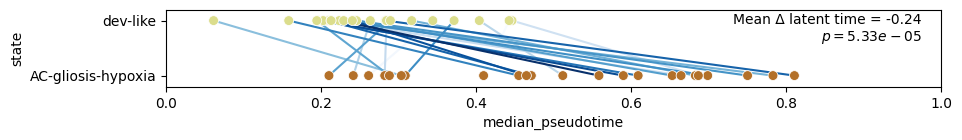

In [ ]:
import matplotlib.cm as cm

plotdf = dev_acgliosis_summary

plotdf["state"] = pd.Categorical(
    plotdf["state"],
    categories=["dev-like", "AC-gliosis-hypoxia"],
    ordered=True
)

fig, ax = plt.subplots(figsize=(10,1))

sns.scatterplot(data = plotdf,
                y = 'state', x = 'median_pseudotime',
                hue = 'state',
                s = 50,
                palette = palette)
sns.lineplot(data = plotdf,
             y = 'state', x = 'median_pseudotime',
             hue = 'diversity',
             units = 'Patient_Clone',
             palette = cm.Blues,
             estimator=None,
             zorder=-1)

plt.margins(y=0.2)
plt.xlim(0,1)

# x position and y span
x = 0.9
y1, y2 = 0.1, 0.9

# label
ax.legend_.remove()

delta = dev_acgliosis_wide['delta_dev_mins_acgliosis_median_pt'].mean()
p = wilcox_dev_acgliosis[1]
label = f"$p = {p:.2e}$"

ax.text(x+0.075, 0.15, "Mean Δ latent time = {}\n{}".format(round(delta, 2), label), 
        ha="right", va="center", color = 'black')

plotdf.to_csv('../../../data/Fig5/Fig5a4.csv')

plt.savefig(outdir+'wilcoxon_plot.pdf')